# 03 — EDA Overview

**Student:** Nosirov Nodir  
**Group:** Tulpar

This short notebook gives the first exploratory overview of the cleaned weekly FOODS dataset. It checks the dataset size, date range, business dimensions, chronological splits, sample rows, and total weekly demand. No features or models are created here.

## 1. Load the processed Parquet dataset

PyArrow reads the 38 Parquet parts as one logical dataset. Only the columns needed for this overview are loaded.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import pyarrow.compute as pc
import pyarrow.dataset as pads
from IPython.display import display

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

def find_project_root():
    candidates = [Path.cwd(), Path.cwd().parent, Path("/content/retail-demand-forecasting")]
    for candidate in candidates:
        if (candidate / "data" / "processed" / "m5_foods_weekly").exists():
            return candidate.resolve()
    raise FileNotFoundError("Processed FOODS data was not found. Run notebook 02 first.")

PROJECT_ROOT = find_project_root()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / "m5_foods_weekly"
REPORT_DIR = PROJECT_ROOT / "reports"
REPORT_DIR.mkdir(exist_ok=True)
dataset = pads.dataset(PROCESSED_DIR, format="parquet")

print("Parquet parts:", len(list(PROCESSED_DIR.glob('part_*.parquet'))))
print("Dataset rows:", f"{dataset.count_rows():,}")

Parquet parts: 38
Dataset rows: 3,118,862


## 2. Dataset dimensions and date range

Count-distinct operations are performed directly on Arrow columns. This avoids loading millions of repeated text values into a large Pandas DataFrame.

In [2]:
dimension_columns = ["item_id", "dept_id", "store_id", "state_id", "week_start", "week_end"]
dimensions = dataset.to_table(columns=dimension_columns)

overview = pd.DataFrame([
    {"metric": "model_ready_rows", "value": dataset.count_rows()},
    {"metric": "products", "value": pc.count_distinct(dimensions["item_id"]).as_py()},
    {"metric": "departments", "value": pc.count_distinct(dimensions["dept_id"]).as_py()},
    {"metric": "stores", "value": pc.count_distinct(dimensions["store_id"]).as_py()},
    {"metric": "states", "value": pc.count_distinct(dimensions["state_id"]).as_py()},
    {"metric": "weeks", "value": pc.count_distinct(dimensions["week_start"]).as_py()},
    {"metric": "first_week_start", "value": str(pc.min(dimensions["week_start"]).as_py().date())},
    {"metric": "last_week_end", "value": str(pc.max(dimensions["week_end"]).as_py().date())},
])
display(overview)

,metric,value
0,model_ready_rows,3118862
1,products,1437
2,departments,3
3,stores,10
4,states,3
5,weeks,277
6,first_week_start,2011-01-31
7,last_week_end,2016-05-22


## 3. Chronological split statistics

The table confirms how many observations belong to train, validation, and test and gives the first demand-level comparison. The test period remains descriptive only; it is not used to choose a model.

In [3]:
analysis_table = dataset.to_table(columns=["week_start", "weekly_units_sold", "dataset_split"])
analysis_table = analysis_table.append_column("is_zero_week", pc.equal(analysis_table["weekly_units_sold"], 0))

split_statistics = analysis_table.group_by("dataset_split").aggregate([
    ("weekly_units_sold", "count"),
    ("weekly_units_sold", "mean"),
    ("weekly_units_sold", "min"),
    ("weekly_units_sold", "max"),
    ("is_zero_week", "sum"),
]).to_pandas()
split_statistics = split_statistics.rename(columns={
    "weekly_units_sold_count": "rows",
    "weekly_units_sold_mean": "mean_weekly_units",
    "weekly_units_sold_min": "minimum_weekly_units",
    "weekly_units_sold_max": "maximum_weekly_units",
    "is_zero_week_sum": "zero_demand_weeks",
})
split_statistics["zero_demand_pct"] = 100 * split_statistics["zero_demand_weeks"] / split_statistics["rows"]
split_order = pd.CategoricalDtype(["train", "validation", "test"], ordered=True)
split_statistics["dataset_split"] = split_statistics["dataset_split"].astype(split_order)
split_statistics = split_statistics.sort_values("dataset_split").reset_index(drop=True)
display(split_statistics)

,dataset_split,rows,mean_weekly_units,minimum_weekly_units,maximum_weekly_units,zero_demand_weeks,zero_demand_pct
0,train,3003902,14.73,0,3976,622343,20.72
1,validation,57480,13.76,0,862,7095,12.34
2,test,57480,14.48,0,938,4960,8.63


## 4. Real cleaned rows

This sample makes the processed structure visible before deeper analysis.

In [4]:
sample = dataset.head(10).to_pandas()
display(sample)

,id,item_id,dept_id,cat_id,store_id,state_id,week_start,weekly_units_sold,days_observed,zero_sales_days,max_daily_sales,sales_outlier_days,week_end,calendar_days,event_days,event_names,price_coverage_days,sell_price_min,sell_price_max,sell_price_mean,snap_days,has_sales_outlier,dataset_split
0,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,2011-01-31,9,7,3,4,0,2011-02-06,7,1,SuperBowl,7,2.00,2.00,2.00,6,0,train
1,FOODS_1_002_CA_1_evaluation,FOODS_1_002,FOODS_1,FOODS,CA_1,CA,2011-01-31,3,7,4,1,0,2011-02-06,7,1,SuperBowl,7,7.88,7.88,7.88,6,0,train
2,FOODS_1_003_CA_1_evaluation,FOODS_1_003,FOODS_1,FOODS,CA_1,CA,2011-01-31,7,7,2,3,0,2011-02-06,7,1,SuperBowl,7,2.88,2.88,2.88,6,0,train
3,FOODS_1_005_CA_1_evaluation,FOODS_1_005,FOODS_1,FOODS,CA_1,CA,2011-01-31,12,7,1,3,0,2011-02-06,7,1,SuperBowl,7,2.94,2.94,2.94,6,0,train
4,FOODS_1_006_CA_1_evaluation,FOODS_1_006,FOODS_1,FOODS,CA_1,CA,2011-01-31,24,7,1,10,0,2011-02-06,7,1,SuperBowl,7,1.97,1.97,1.97,6,0,train
5,FOODS_1_011_CA_1_evaluation,FOODS_1_011,FOODS_1,FOODS,CA_1,CA,2011-01-31,3,7,6,3,0,2011-02-06,7,1,SuperBowl,7,2.28,2.28,2.28,6,0,train
6,FOODS_1_013_CA_1_evaluation,FOODS_1_013,FOODS_1,FOODS,CA_1,CA,2011-01-31,11,7,2,3,0,2011-02-06,7,1,SuperBowl,7,1.25,1.25,1.25,6,0,train
7,FOODS_1_016_CA_1_evaluation,FOODS_1_016,FOODS_1,FOODS,CA_1,CA,2011-01-31,10,7,2,4,0,2011-02-06,7,1,SuperBowl,7,1.96,1.96,1.96,6,0,train
8,FOODS_1_018_CA_1_evaluation,FOODS_1_018,FOODS_1,FOODS,CA_1,CA,2011-01-31,33,7,1,12,0,2011-02-06,7,1,SuperBowl,7,1.00,1.00,1.00,6,0,train
9,FOODS_1_019_CA_1_evaluation,FOODS_1_019,FOODS_1,FOODS,CA_1,CA,2011-01-31,37,7,1,16,0,2011-02-06,7,1,SuperBowl,7,0.97,0.97,0.97,6,0,train


## 5. Total weekly FOODS demand

The line chart gives the first view of trend and seasonality. Vertical lines show where validation and test begin. Detailed store, department, price, event, and outlier analysis belongs to later EDA steps.

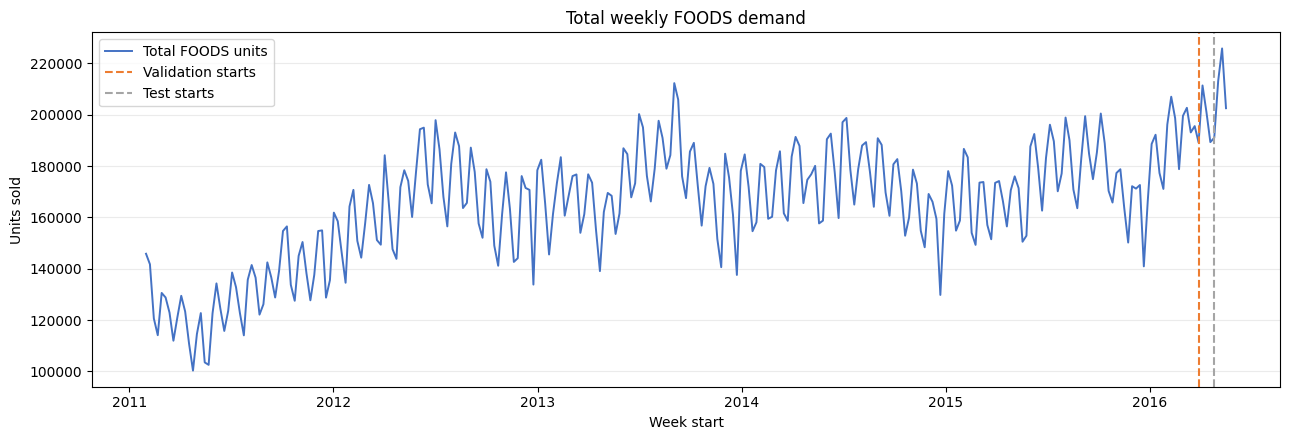

In [5]:
weekly_overview = analysis_table.group_by("week_start").aggregate([
    ("weekly_units_sold", "sum"),
    ("weekly_units_sold", "mean"),
    ("weekly_units_sold", "count"),
]).to_pandas().rename(columns={
    "weekly_units_sold_sum": "total_units",
    "weekly_units_sold_mean": "mean_units_per_series",
    "weekly_units_sold_count": "active_series",
}).sort_values("week_start")

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(weekly_overview["week_start"], weekly_overview["total_units"], color="#4472C4", linewidth=1.4, label="Total FOODS units")
ax.axvline(pd.Timestamp("2016-03-28"), color="#ED7D31", linestyle="--", linewidth=1.5, label="Validation starts")
ax.axvline(pd.Timestamp("2016-04-25"), color="#A5A5A5", linestyle="--", linewidth=1.5, label="Test starts")
ax.set_title("Total weekly FOODS demand")
ax.set_xlabel("Week start")
ax.set_ylabel("Units sold")
ax.legend()
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## 6. Save and verify the short EDA report

Small CSV reports are committed to GitHub. The large processed dataset remains local.

In [6]:
expected_split_rows = {"train": 3_003_902, "validation": 57_480, "test": 57_480}
actual_split_rows = dict(zip(split_statistics["dataset_split"].astype(str), split_statistics["rows"].astype(int)))
assert dataset.count_rows() == 3_118_862
assert actual_split_rows == expected_split_rows
assert int(overview.loc[overview["metric"].eq("products"), "value"].iloc[0]) == 1_437
assert int(overview.loc[overview["metric"].eq("stores"), "value"].iloc[0]) == 10
assert not weekly_overview.isna().any().any()

overview.to_csv(REPORT_DIR / "eda_overview_summary.csv", index=False)
split_statistics.to_csv(REPORT_DIR / "eda_split_statistics.csv", index=False)
weekly_overview.to_csv(REPORT_DIR / "eda_weekly_overview.csv", index=False)

print("EDA-1 checks passed.")
print("Weekly observations:", len(weekly_overview))
print("Reports saved in:", REPORT_DIR)

EDA-1 checks passed.
Weekly observations: 277
Reports saved in: F:\7) AI-ML_Fundamental_Project\Git_Desktop\retail-demand-forecasting\reports


## 7. Initial conclusion

The cleaned dataset has enough history, products, and stores for a meaningful forecasting project. The split sizes are correct and the timeline is continuous. Demand changes visibly over time, so later features must use past-week lags and rolling statistics rather than a random split.